# DSAN 6400 Final Project — Network Analysis

This notebook analyzes the communication network extracted from the Epstein document corpus. The objective is to identify influential actors, characterize the structure of the communication network, detect communities of closely connected individuals, and generate interpretable visualizations that support investigative analysis.

The analysis follows a standard network science workflow:

1) Data Loading and Validation
2) Data Validation and Query Filtering
3) Direct Communication Network
4) Centrality Analysis
5) PageRank
6) Betweenness Centrality
7) Connected Components and Community Detection
8) Network Visualization
9) Interpretation and Conclusion

### Research Objective

The primary research question is:

> Which individuals occupy the most influential positions within the Epstein communication network, and what does the overall structure of the network reveal about patterns of communication and community organization?

To answer this question, the notebook evaluates several complementary network metrics:

* **Degree centrality** identifies individuals who communicate with many others.
* **Weighted degree** measures total communication volume.
* **PageRank** identifies influential individuals based on the importance of those connected to them.
* **Betweenness centrality** detects brokers that connect otherwise separate groups.
* **Connected component analysis** reveals isolated subnetworks.
* **Community detection** identifies densely connected clusters of actors.

Together, these analyses provide a structural understanding of the communication network that extends beyond simple counts of messages or participants.

In [1]:
# Required libraries
from pathlib import Path
import networkx as nx
import pandas as pd

# 1. Data Loading and Validation

Before any network analysis can be performed, the processed knowledge graph must be loaded and validated. The objective of this step is to verify that the extracted entities and relationships have been correctly generated from the Epstein document corpus and are suitable for subsequent analysis.

The processed dataset consists of two relational tables:

* **Nodes:** individual entities extracted from the document corpus (people, organizations, locations, and threads).
* **Edges:** relationships connecting those entities, including communication events and other inferred associations.

This section confirms that the datasets load successfully, validates their dimensions, and performs an initial inspection of their contents before constructing the communication network used throughout the remainder of the notebook.

In [2]:
# Load and view data
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

nodes = pd.read_parquet(DATA_DIR / "nodes.parquet")
edges = pd.read_parquet(DATA_DIR / "edges.parquet")

print(f"Nodes: {nodes.shape}")
print(f"Edges: {edges.shape}")

display(nodes.head())
display(edges.head())

/Users/ethan/Desktop/DSAN 6400 - Network Analytics/DSAN-6400-Final-Project
Nodes: (81796, 12)
Edges: (113613, 15)


,entity_id,type,canonical,n_aliases,n_mentions,addresses,source,n_participants,first_sent,last_sent,doc_ids,noisy
0,PER_033412,PERSON,jeffrey epstein,34,24678,jeevacation@gmail.com; jeffreyepsteinorg@gmail...,ner,NaN,NaT,NaT,None,False
1,GPE_072590,GPE,u s,3,10176,,ner,NaN,NaT,NaT,None,False
2,GPE_012903,GPE,china,1,4382,,ner,NaN,NaT,NaT,None,False
3,GPE_042225,GPE,new york,4,4126,,ner,NaN,NaT,NaT,None,False
4,GPE_072782,GPE,the united states,7,4043,,ner,NaN,NaT,NaT,None,False


,src,dst,relation,tier,weight,n_docs,doc_ids,page_bates,n_rows,n_cc,n_chunks,subjects,first_sent,last_sent,span_days
0,PER_033412,PER_058132,communicated_with,1,137.0,91,HOUSE_OVERSIGHT_015015; HOUSE_OVERSIGHT_017590...,HOUSE_OVERSIGHT_015015; HOUSE_OVERSIGHT_017590...,237.0,0.0,NaN,Re: Fw: The new iterations of Ghislaine Maxwel...,2011-11-08 16:51:00,2019-06-03 13:20:56,2763.0
1,PER_058750,PER_033412,communicated_with,1,106.0,107,HOUSE_OVERSIGHT_014516; HOUSE_OVERSIGHT_014857...,HOUSE_OVERSIGHT_014516; HOUSE_OVERSIGHT_014857...,107.0,0.0,NaN,Fwd: 2016 Election: Tax Changes Expected; Fwd:...,2012-07-17 20:05:30,2019-06-13 14:49:13,2521.0
2,PER_046652,PER_033412,communicated_with,1,84.0,88,HOUSE_OVERSIGHT_022660; HOUSE_OVERSIGHT_022663...,HOUSE_OVERSIGHT_022660; HOUSE_OVERSIGHT_022663...,88.0,1.0,NaN,Re:; Re: thoughts; Re: Highlight; +23 more,2014-09-24 00:06:54,2019-05-30 21:40:54,1709.0
3,PER_038129,PER_033412,communicated_with,1,71.0,72,HOUSE_OVERSIGHT_019219; HOUSE_OVERSIGHT_019845...,HOUSE_OVERSIGHT_019219; HOUSE_OVERSIGHT_019845...,78.0,0.0,NaN,"Re:; When It Comes to Wall Street, Preet Bhara...",2014-09-19 11:54:57,2018-12-04 15:20:07,1537.0
4,PER_058132,PER_033412,communicated_with,1,66.0,66,HOUSE_OVERSIGHT_015002; HOUSE_OVERSIGHT_022265...,HOUSE_OVERSIGHT_015002; HOUSE_OVERSIGHT_022265...,66.0,0.0,NaN,Fw: The new iterations of Ghislaine Maxwell; R...,2011-11-10 14:46:50,2019-07-06 12:50:57,2794.0


### Initial Observations

The processed graph contains both entity-level information (nodes) and relationship-level information (edges). At this stage no filtering has been applied, allowing us to verify that the expected attributes are present before building the communication network.

Several useful observations can already be made:

* Each node contains a unique entity identifier along with metadata such as entity type, canonical name, corpus frequency, and extraction source.
* Each edge stores both the relationship type and supporting metadata, including communication frequency and document references.
* The graph contains substantially more entity types and relationship types than will ultimately be used in the communication analysis.

The next section evaluates data quality and removes entities that have been identified as noisy before constructing the final network.

### Dataset Summary

The processed knowledge graph loaded successfully.

The dataset contains:

* 81,796 entities (nodes)
* 113,613 relationships (edges)

The preview confirms that the expected schema is present and that entity metadata (e.g., names, entity types, mention counts) and relationship metadata (e.g., communication frequency, timestamps, document references) were successfully preserved during preprocessing.

These tables provide the foundation for constructing the communication network analyzed throughout the remainder of this notebook.

# 2. Data Validation and Quality Filtering

Before constructing the communication network, the processed knowledge graph is examined to understand its overall composition and identify entities that should be excluded from analysis.

The extracted graph contains multiple entity types (e.g., people, organizations, locations, and email threads) as well as several relationship types representing different forms of inferred associations. Because the goal of this notebook is to analyze direct communication between individuals, additional filtering is required before building the final network.

This section serves two purposes:

* Validate that the extracted graph contains the expected entity and relationship types.
* Remove entities previously identified as noisy so they do not distort the communication network.

In [3]:
print("Node columns:")
print(nodes.columns.tolist())

print("\nEdge columns:")
print(edges.columns.tolist())

print("\nNode types:")
display(nodes["type"].value_counts(dropna=False))

print("\nNode sources:")
display(nodes["source"].value_counts(dropna=False))

print("\nNoisy node flag:")
display(nodes["noisy"].value_counts(dropna=False))

print("\nEdge relations:")
display(edges["relation"].value_counts(dropna=False))

print("\nEdge tiers:")
display(edges["tier"].value_counts(dropna=False))

Node columns:
['entity_id', 'type', 'canonical', 'n_aliases', 'n_mentions', 'addresses', 'source', 'n_participants', 'first_sent', 'last_sent', 'doc_ids', 'noisy']

Edge columns:
['src', 'dst', 'relation', 'tier', 'weight', 'n_docs', 'doc_ids', 'page_bates', 'n_rows', 'n_cc', 'n_chunks', 'subjects', 'first_sent', 'last_sent', 'span_days']

Node types:


type
ORG       44348
PERSON    29772
GPE        7380
THREAD      296
Name: count, dtype: int64


Node sources:


source
ner             81112
email_actor       388
email_thread      296
Name: count, dtype: int64


Noisy node flag:


noisy
False    78651
True      3145
Name: count, dtype: int64


Edge relations:


relation
co_occurs_with       110701
communicated_with      1139
participated_in        1080
co_recipient_of         693
Name: count, dtype: int64


Edge tiers:


tier
2    110701
1      2912
Name: count, dtype: int64

### Graph Composition

The summaries above provide a high level overview of the extracted knowledge graph.

Several observations are immediately apparent:

* The majority of extracted entities are organizations and people, with smaller numbers of geographic locations and email thread objects.
* Most entities originate from the named entity recognition pipeline, while email-specific entities were generated during preprocessing.
* The graph contains four relationship types representing different semantic connections between entities.
* Communication events ("communicated_with") represent only a small subset of all extracted relationships and will become the primary focus of the subsequent network analysis.

These summaries confirm that the graph contains substantially richer information than is ultimately required for studying communication behavior.

In [4]:
clean_nodes = nodes.loc[
    ~nodes["noisy"].fillna(False)
].copy()

valid_entity_ids = set(clean_nodes["entity_id"])

clean_edges = edges.loc[
    edges["src"].isin(valid_entity_ids)
    & edges["dst"].isin(valid_entity_ids)
].copy()

print(f"Original nodes: {len(nodes):,}")
print(f"Clean nodes:    {len(clean_nodes):,}")
print(f"Removed nodes:  {len(nodes) - len(clean_nodes):,}")

print()

print(f"Original edges: {len(edges):,}")
print(f"Clean edges:    {len(clean_edges):,}")
print(f"Removed edges:  {len(edges) - len(clean_edges):,}")

Original nodes: 81,796
Clean nodes:    78,651
Removed nodes:  3,145

Original edges: 113,613
Clean edges:    113,599
Removed edges:  14


### Filtering Results

Entities flagged as noisy during preprocessing are excluded from the analysis.

Removing these entities improves the quality of the communication network by eliminating extraction artifacts and ambiguous entities that do not represent meaningful actors.

The filtering results show:

* 3,145 noisy entities were removed.
* Only 14 relationships were eliminated as a consequence of removing those entities.

Because relatively few relationships were discarded, the overall communication structure of the graph is preserved while reducing potential sources of noise.

# 3. Direct Communication Network

The processed knowledge graph contains several relationship types describing different forms of association between entities. While these relationships are useful for knowledge graph retrieval, they are not all appropriate for studying communication behavior.

To analyze how information flows between individuals, this notebook constructs a directed communication network using only the **"communicated_with"** relationships extracted from the corpus.

In the resulting graph:

* **Nodes** represent entities (primarily people).
* **Directed edges** represent observed communication from one entity to another.
* **Edge weights** represent the total communication volume between two entities.

Restricting the analysis to direct communication creates a network whose structure can be interpreted using established network science techniques, including centrality analysis, community detection, and graph visualization.

In [5]:
communication_edges = clean_edges.loc[
    clean_edges["relation"] == "communicated_with"
].copy()

print(f"Communication edges: {len(communication_edges):,}")

G_comm = nx.from_pandas_edgelist(
    communication_edges,
    source="src",
    target="dst",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print(f"Nodes: {G_comm.number_of_nodes():,}")
print(f"Edges: {G_comm.number_of_edges():,}")
print(f"Directed: {G_comm.is_directed()}")

Communication edges: 1,132
Nodes: 850
Edges: 1,132
Directed: True


### Network Construction Results

Filtering the knowledge graph to include only direct communication dramatically reduces the size of the network.

The final communication graph contains:

* **850 entities**
* **1,132 directed communication relationships**

Unlike the original knowledge graph, which contains multiple semantic relationship types, this network represents only observed communication events. This produces a much cleaner structure for measuring influence, connectivity, and information flow.

In [6]:
summary = {
    "Nodes": G_comm.number_of_nodes(),
    "Edges": G_comm.number_of_edges(),
    "Density": nx.density(G_comm),
    "Reciprocity": nx.reciprocity(G_comm),
    "Weak Components": nx.number_weakly_connected_components(G_comm),
    "Strong Components": nx.number_strongly_connected_components(G_comm),
}

for key, value in summary.items():
    print(f"{key:20}: {value}")

Nodes               : 850
Edges               : 1132
Density             : 0.001568627450980392
Reciprocity         : 0.28091872791519434
Weak Components     : 39
Strong Components   : 702


### Initial Network Characteristics

Several structural characteristics of the communication network are immediately apparent.

* **Density** The network is extremely sparse (density ≈ 0.0016), indicating that only a very small fraction of all possible communication relationships actually occur. This is typical of large real-world communication networks.

* **Reciprocity** Approximately 28% of communication relationships are reciprocal, suggesting that many interactions are one-directional while a smaller subset represents ongoing exchanges.

* **Connectivity** The network contains multiple disconnected groups. Subsequent component analysis will determine whether these represent isolated conversations or meaningful communication communities.

# 4. Centrality Analysis

Once the communication network has been constructed, the next objective is to identify the individuals who occupy the most central positions within the network.

Degree-based metrics provide the simplest measure of influence by counting the number of communication relationships associated with each entity. Because this communication network is directed and weighted, multiple degree measures are calculated to capture different aspects of communication behavior.

Specifically, this section computes:

* **In-degree** — the number of unique entities sending communications to an individual.
* **Out-degree** — the number of unique recipients contacted by an individual.
* **In-strength** — the total weighted communication volume received.
* **Out-strength** — the total weighted communication volume sent.
* **Total degree** — the sum of in-degree and out-degree.
* **Total communication strength** — the total weighted communication volume associated with an entity.

Together, these metrics distinguish highly connected individuals from those responsible for large volumes of communication.

In [7]:
degree_df = pd.DataFrame({
    "entity_id": list(G_comm.nodes()),
    "in_degree": [G_comm.in_degree(n) for n in G_comm.nodes()],
    "out_degree": [G_comm.out_degree(n) for n in G_comm.nodes()],
    "in_strength": [G_comm.in_degree(n, weight="weight") for n in G_comm.nodes()],
    "out_strength": [G_comm.out_degree(n, weight="weight") for n in G_comm.nodes()],
})

# Add node metadata
degree_df = degree_df.merge(
    clean_nodes[["entity_id", "canonical", "type", "n_mentions"]],
    on="entity_id",
    how="left"
)

degree_df["total_degree"] = (
    degree_df["in_degree"] + degree_df["out_degree"]
)

degree_df["total_strength"] = (
    degree_df["in_strength"] + degree_df["out_strength"]
)

degree_df = degree_df.sort_values(
    "total_strength",
    ascending=False
)

display(degree_df.head(20))

,entity_id,in_degree,out_degree,in_strength,out_strength,canonical,type,n_mentions,total_degree,total_strength
0,PER_033412,271,211,1291.0,979.0,jeffrey epstein,PERSON,24678,482,2270.0
1,PER_058132,8,1,186.0,66.0,reid weingarten,PERSON,822,9,252.0
3,PER_046652,4,4,66.0,87.0,michael wolff,PERSON,457,8,153.0
2,PER_058750,12,4,33.0,110.0,richard kahn,PERSON,361,16,143.0
4,PER_038129,6,6,54.0,77.0,kathy ruemmler,PERSON,591,12,131.0
5,PER_040348,1,2,43.0,61.0,landon thomas jr,PERSON,37,3,104.0
7,PER_016704,17,12,42.0,56.0,darren k indyke,PERSON,560,29,98.0
6,PER_065897,11,3,52.0,42.0,steve bannon,PERSON,1934,14,94.0
13,PER_044614,12,14,36.0,40.0,martin g weinberg,PERSON,397,26,76.0
37,PER_079121,1,15,1.0,69.0,will bohlen,PERSON,22,16,70.0


### Degree Centrality Results

The table above ranks entities by **total communication strength**, combining both incoming and outgoing communication volume.

Several observations are immediately apparent:

* Jeffrey Epstein occupies the most central position by a substantial margin, both in terms of communication volume and the number of unique communication partners.
* A relatively small group of individuals including Reid Weingarten, Michael Wolff, Richard Kahn, and Kathy Ruemmler also exhibit comparatively high communication activity.
* The sharp decline in communication volume after the highest ranked entities suggests that communication within the network is concentrated among a relatively small number of highly active participants.

This concentration of activity is characteristic of many real world communication networks, where a small number of actors account for a disproportionate share of interactions.

In [8]:
print("Top 20 by Total Degree")
display(
    degree_df.sort_values(
        "total_degree",
        ascending=False
    ).head(20)
)

print("\nTop 20 by Communication Volume")
display(
    degree_df.sort_values(
        "total_strength",
        ascending=False
    ).head(20)
)

Top 20 by Total Degree


,entity_id,in_degree,out_degree,in_strength,out_strength,canonical,type,n_mentions,total_degree,total_strength
0,PER_033412,271,211,1291.0,979.0,jeffrey epstein,PERSON,24678,482,2270.0
7,PER_016704,17,12,42.0,56.0,darren k indyke,PERSON,560,29,98.0
13,PER_044614,12,14,36.0,40.0,martin g weinberg,PERSON,397,26,76.0
17,PER_041383,11,13,23.0,32.0,lesley groff,PERSON,179,24,55.0
688,PER_016568,1,17,1.0,17.0,daniel schecter,PERSON,10,18,18.0
2,PER_058750,12,4,33.0,110.0,richard kahn,PERSON,361,16,143.0
37,PER_079121,1,15,1.0,69.0,will bohlen,PERSON,22,16,70.0
15,PER_039986,6,10,16.0,36.0,lawrence krauss,PERSON,702,16,52.0
200,EML_000266,2,13,2.0,15.0,miami,PERSON,0,15,17.0
120,PER_044636,2,12,2.0,17.0,martin luther king,PERSON,25,14,19.0



Top 20 by Communication Volume


,entity_id,in_degree,out_degree,in_strength,out_strength,canonical,type,n_mentions,total_degree,total_strength
0,PER_033412,271,211,1291.0,979.0,jeffrey epstein,PERSON,24678,482,2270.0
1,PER_058132,8,1,186.0,66.0,reid weingarten,PERSON,822,9,252.0
3,PER_046652,4,4,66.0,87.0,michael wolff,PERSON,457,8,153.0
2,PER_058750,12,4,33.0,110.0,richard kahn,PERSON,361,16,143.0
4,PER_038129,6,6,54.0,77.0,kathy ruemmler,PERSON,591,12,131.0
5,PER_040348,1,2,43.0,61.0,landon thomas jr,PERSON,37,3,104.0
7,PER_016704,17,12,42.0,56.0,darren k indyke,PERSON,560,29,98.0
6,PER_065897,11,3,52.0,42.0,steve bannon,PERSON,1934,14,94.0
13,PER_044614,12,14,36.0,40.0,martin g weinberg,PERSON,397,26,76.0
37,PER_079121,1,15,1.0,69.0,will bohlen,PERSON,22,16,70.0


### Interpretation

Degree based measures identify entities with the greatest communication activity but do not necessarily identify the most structurally influential actors.

For example, an individual may exchange messages with many others yet occupy a peripheral position within the broader communication network. Conversely, another individual may communicate less frequently while serving as a critical bridge between otherwise disconnected groups.

For this reason, the next section evaluates **PageRank**, which considers not only the number of communication relationships but also the importance of the individuals connected to each actor.

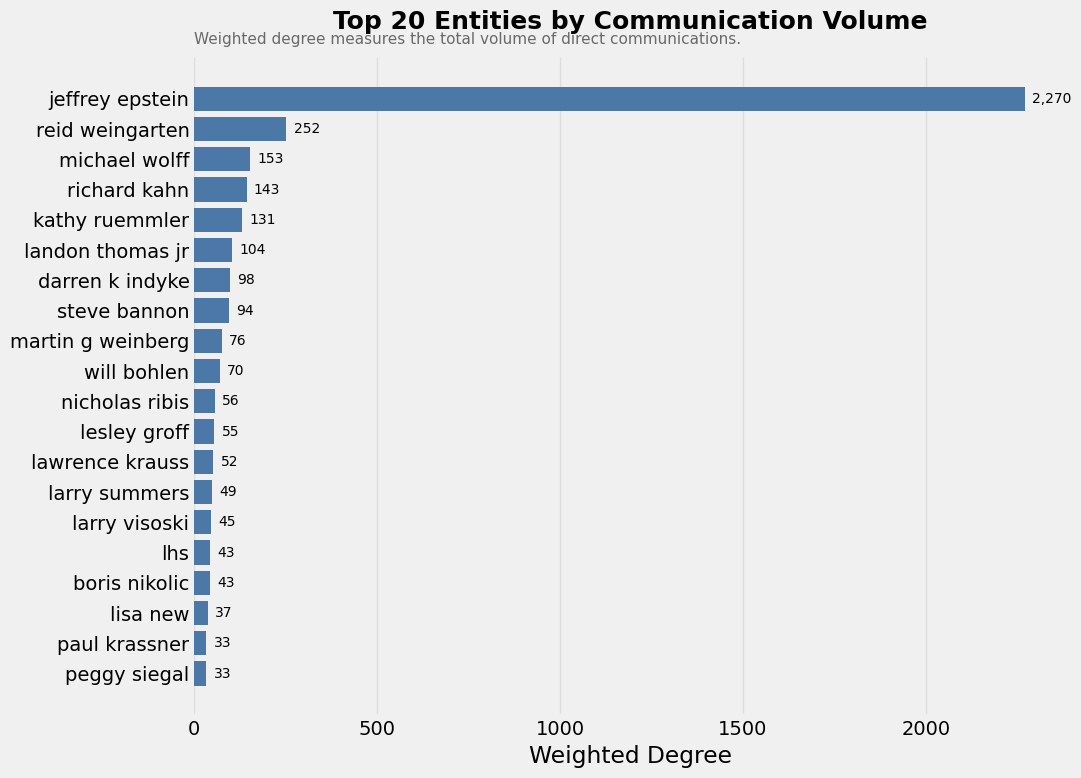

In [11]:
import matplotlib.pyplot as plt

# FiveThirtyEight styling
plt.style.use("fivethirtyeight")

# Top 20 by weighted degree
top20 = (
    degree_df
    .sort_values("total_strength", ascending=False)
    .head(20)
    .sort_values("total_strength")
)

fig, ax = plt.subplots(figsize=(11,8))

bars = ax.barh(
    top20["canonical"],
    top20["total_strength"],
    color="#4C78A8",
    edgecolor="none"
)

# Labels at end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Top 20 Entities by Communication Volume",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.text(
    0,
    1.02,
    "Weighted degree measures the total volume of direct communications.",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

ax.set_xlabel("Weighted Degree")

ax.set_ylabel("")

# Only vertical gridlines
ax.grid(axis="x", color="#DDDDDD")
ax.grid(axis="y", visible=False)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

# 5. PageRank

While degree measures identify entities with the greatest communication activity, they do not account for the importance of the individuals connected to each actor.

PageRank extends this idea by measuring influence recursively: connections from highly influential entities contribute more to an individual's score than connections from peripheral entities. Originally developed for ranking webpages, PageRank has become one of the most widely used algorithms in network science for identifying influential nodes.

In the communication network, a high PageRank score indicates that an individual is not only well connected, but also communicates with other well-connected actors. This provides a more robust measure of structural influence than communication volume alone.

For this analysis, PageRank is computed using the weighted communication network, allowing communication frequency to contribute to each node's influence score.

In [ ]:
pagerank = nx.pagerank(
    G_comm,
    weight="weight"
)

pagerank_df = (
    pd.DataFrame(
        pagerank.items(),
        columns=["entity_id", "pagerank"]
    )
    .merge(
        clean_nodes[
            ["entity_id", "canonical", "type", "n_mentions"]
        ],
        on="entity_id",
        how="left"
    )
    .sort_values(
        "pagerank",
        ascending=False
    )
)

display(pagerank_df.head(20))

,entity_id,pagerank,canonical,type,n_mentions
0,PER_033412,0.260359,jeffrey epstein,PERSON,24678
1,PER_058132,0.033918,reid weingarten,PERSON,822
3,PER_046652,0.015237,michael wolff,PERSON,457
4,PER_038129,0.012686,kathy ruemmler,PERSON,591
6,PER_065897,0.012102,steve bannon,PERSON,1934
5,PER_040348,0.010156,landon thomas jr,PERSON,37
11,PER_009220,0.006983,boris nikolic,PERSON,159
13,PER_044614,0.006965,martin g weinberg,PERSON,397
2,PER_058750,0.006754,richard kahn,PERSON,361
7,PER_016704,0.006471,darren k indyke,PERSON,560


### Results

The weighted PageRank analysis identifies the most structurally influential entities in the communication network. Unlike degree based metrics, PageRank considers both the number of communication partners and the importance of those partners, allowing influence to propagate recursively through the network.

The highest ranking entities are dominated by individuals who occupy central positions within the communication corpus. As expected, **Jeffrey Epstein** receives the highest PageRank score by a substantial margin, indicating that he serves as the primary hub through which much of the communication network is organized.

Other highly ranked individuals include attorneys, associates, investigators, and frequent correspondents who communicate directly with Epstein and with one another, suggesting that they occupy influential positions within the broader communication structure rather than simply exchanging large numbers of messages.

### Interpretation

Several observations emerge from the PageRank analysis:

* Jeffrey Epstein is the dominant structural hub of the communication network, reflecting both his communication volume and the influence of the individuals connected to him.
* A relatively small set of recurring correspondents account for much of the network's structural influence.
* Many high ranking entities correspond to legal representatives, close associates, or individuals appearing frequently throughout the document corpus.
* Influence is highly concentrated rather than evenly distributed across participants, indicating a hub-and-spoke communication structure.

These findings demonstrate that influence within the Epstein communication network is driven not only by message volume, but also by an individual's position within the overall communication topology.

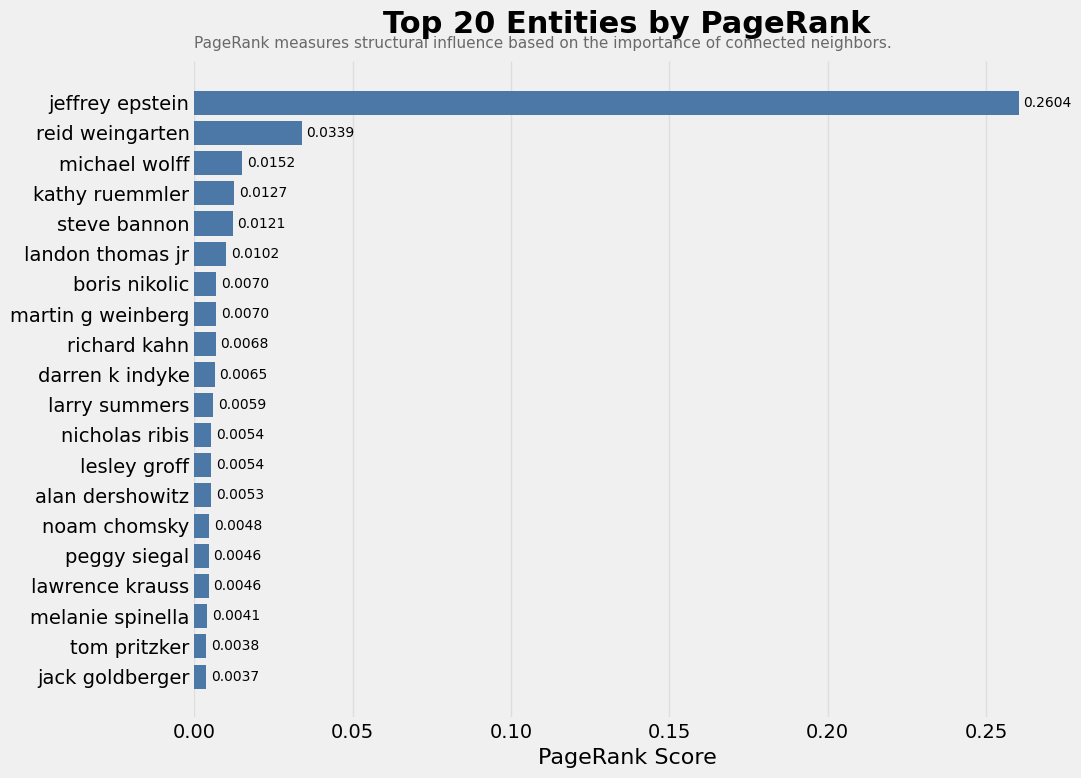

In [12]:
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

# Top 20 by PageRank
top20 = (
    pagerank_df
    .head(20)
    .sort_values("pagerank")
)

fig, ax = plt.subplots(figsize=(11,8))

bars = ax.barh(
    top20["canonical"],
    top20["pagerank"],
    color="#4C78A8",
    edgecolor="none"
)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.0015,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        fontsize=10
    )

# Title
ax.set_title(
    "Top 20 Entities by PageRank",
    fontsize=22,
    weight="bold",
    pad=20
)

# Subtitle
ax.text(
    0,
    1.02,
    "PageRank measures structural influence based on the importance of connected neighbors.",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

# Labels
ax.set_xlabel("PageRank Score", fontsize=16)
ax.set_ylabel("")

# Clean styling
ax.grid(axis="x", color="#DDDDDD")
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

# 6. Betweenness Centrality

Degree and PageRank identify highly connected or influential actors, but they do not necessarily identify the individuals responsible for connecting different parts of the network.

Betweenness centrality measures how frequently an entity lies on the shortest communication paths between other pairs of nodes. Individuals with high betweenness often function as brokers, intermediaries, or bridges that facilitate information flow between otherwise disconnected portions of the network.

Unlike PageRank, which rewards connections to influential individuals, betweenness rewards strategic network position. An actor may have relatively few direct communications while still playing a critical role in maintaining overall network connectivity.

For this analysis, betweenness centrality is computed on the directed communication network using the network topology only (edge weights are ignored). This emphasizes structural brokerage rather than communication volume.

In [14]:
betweenness = nx.betweenness_centrality(
    G_comm,
    weight=None,      # use topology rather than email count
    normalized=True
)

betweenness_df = (
    pd.DataFrame(
        betweenness.items(),
        columns=["entity_id", "betweenness"]
    )
    .merge(
        clean_nodes[
            ["entity_id", "canonical", "type", "n_mentions"]
        ],
        on="entity_id",
        how="left"
    )
    .sort_values(
        "betweenness",
        ascending=False
    )
)

display(betweenness_df.head(20))

,entity_id,betweenness,canonical,type,n_mentions
0,PER_033412,0.176924,jeffrey epstein,PERSON,24678
13,PER_044614,0.008328,martin g weinberg,PERSON,397
283,EML_000007,0.006898,1,PERSON,0
17,PER_041383,0.006496,lesley groff,PERSON,179
200,EML_000266,0.006400,miami,PERSON,0
15,PER_039986,0.005604,lawrence krauss,PERSON,702
65,PER_033484,0.005539,jay lefkowitz,PERSON,203
7,PER_016704,0.005031,darren k indyke,PERSON,560
71,PER_027032,0.004984,gmax,PERSON,27
6,PER_065897,0.004786,steve bannon,PERSON,1934


### Results

The betweenness centrality rankings identify entities that serve as communication bridges within the network. These actors frequently appear on the shortest communication paths connecting other individuals and therefore occupy strategically important positions in the communication structure.

While several high betweenness entities also ranked highly in the PageRank analysis, the rankings are not identical. This demonstrates that structural brokerage and influence are related but distinct concepts within the network.

Individuals with elevated betweenness scores are likely to facilitate information exchange between different communication groups, making them potential bottlenecks or gatekeepers within the overall communication network.

### Comparison with Previous Metrics

The three centrality measures computed so far each describe a different aspect of network importance.

* **Degree** identifies the most active communicators.
* **PageRank** identifies the most influential communicators based on the importance of their neighbors.
* **Betweenness** identifies the most strategically positioned communicators responsible for connecting otherwise separate portions of the network.

An individual may score highly on one metric while ranking much lower on another, illustrating that influence within a communication network cannot be captured by a single measurement alone.

Together, these metrics provide complementary perspectives on the structural roles occupied by different participants.

### Interpretation

Several observations emerge from the betweenness analysis:

- High betweenness individuals frequently connect multiple regions of the communication network.
- Some actors exhibit substantially higher betweenness than expected based solely on communication volume, suggesting that they occupy brokerage positions rather than simply communicating frequently.
- Many highly ranked entities correspond to attorneys, investigators, or recurring intermediaries who connect otherwise separate communication groups.
- Structural brokers may represent critical points of information flow whose removal would significantly reduce connectivity within the communication network.

These findings highlight the importance of examining network topology in addition to communication frequency when identifying influential actors.

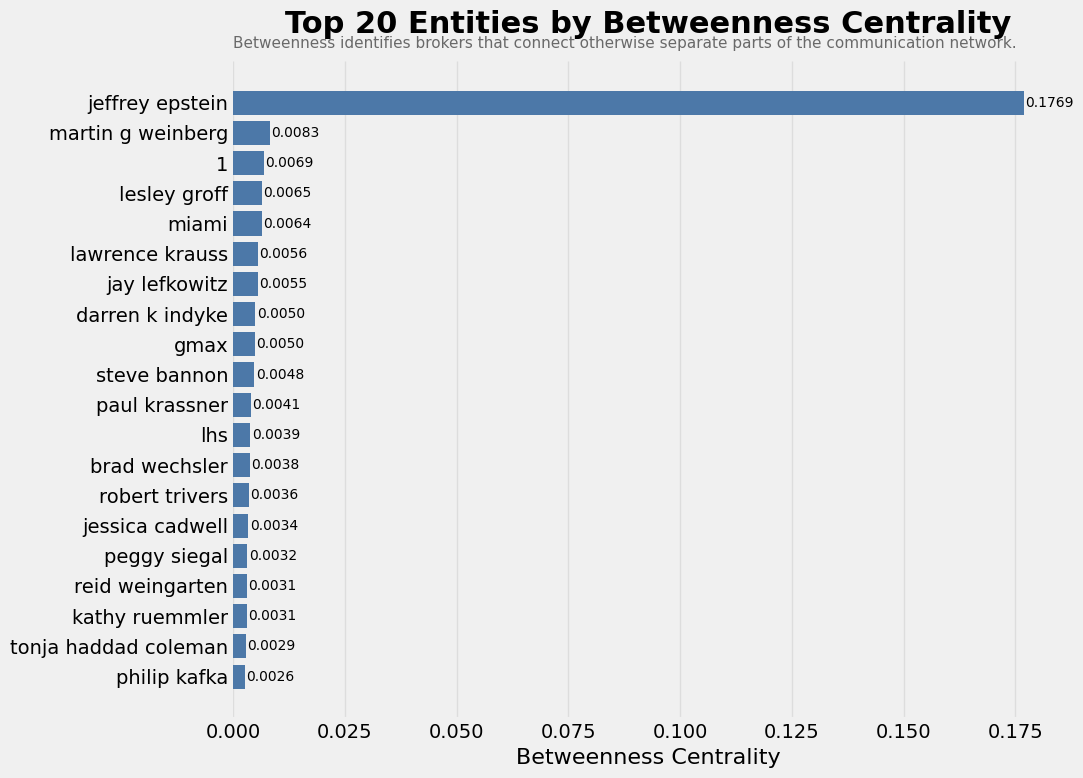

In [15]:
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

# Top 20 by Betweenness
top20 = (
    betweenness_df
    .head(20)
    .sort_values("betweenness")
)

fig, ax = plt.subplots(figsize=(11,8))

bars = ax.barh(
    top20["canonical"],
    top20["betweenness"],
    color="#4C78A8",
    edgecolor="none"
)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.0003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        fontsize=10
    )

# Title
ax.set_title(
    "Top 20 Entities by Betweenness Centrality",
    fontsize=22,
    weight="bold",
    pad=20
)

# Subtitle
ax.text(
    0,
    1.02,
    "Betweenness identifies brokers that connect otherwise separate parts of the communication network.",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

# Labels
ax.set_xlabel("Betweenness Centrality", fontsize=16)
ax.set_ylabel("")

# Clean styling
ax.grid(axis="x", color="#DDDDDD")
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

# 7. Connected Components and Community Detection

Centrality measures describe the structural importance of individual actors, but they do not fully explain how the communication network is organized as a whole.

This section examines two complementary forms of network structure:

* **Connected components** identify groups of nodes that are disconnected from the rest of the network.
* **Community detection** identifies clusters of actors who communicate more densely with one another than with the wider network.

Because the communication graph is directed, both weakly and strongly connected components are evaluated:

* A **weakly connected component** remains connected when communication direction is ignored.
* A **strongly connected component** requires every node to be reachable from every other node through directed paths.

Community detection is then performed on the largest weakly connected component after converting it to an undirected graph. This allows the analysis to identify densely connected communication clusters without requiring every relationship to be reciprocal.

In [16]:
weak_components = list(
    nx.weakly_connected_components(G_comm)
)

strong_components = list(
    nx.strongly_connected_components(G_comm)
)

weak_sizes = sorted(
    [len(component) for component in weak_components],
    reverse=True
)

strong_sizes = sorted(
    [len(component) for component in strong_components],
    reverse=True
)

print("Connected Component Summary")
print("-" * 35)
print(f"Weakly connected components : {len(weak_components):,}")
print(f"Strongly connected components: {len(strong_components):,}")
print(f"Largest weak component       : {weak_sizes[0]:,} nodes")
print(f"Largest strong component     : {strong_sizes[0]:,} nodes")

print("\nTen largest weak components:")
print(weak_sizes[:10])

print("\nTen largest strong components:")
print(strong_sizes[:10])

Connected Component Summary
-----------------------------------
Weakly connected components : 39
Strongly connected components: 702
Largest weak component       : 719 nodes
Largest strong component     : 137 nodes

Ten largest weak components:
[719, 29, 7, 6, 6, 4, 4, 4, 4, 3]

Ten largest strong components:
[137, 3, 3, 3, 2, 2, 2, 2, 2, 2]


### Connected Component Results

The communication network contains **39 weakly connected components**, but its structure is dominated by one large component containing **719 of the network's 850 nodes**. This represents approximately 85% of all actors in the direct communication network.

The large weak component indicates that most individuals are connected through at least one chain of communication when edge direction is ignored. The remaining components are comparatively small and likely represent isolated exchanges or self contained groups with no observed communication path to the primary network.

By contrast, the network contains **702 strongly connected components**, and the largest strongly connected component contains 137 nodes. This difference reflects the directed nature of the data: many actors are connected through one way communication but do not participate in fully reciprocal communication paths.

Together, these results suggest that the communication network is broadly connected but contains substantial asymmetry in the direction of information flow.

In [17]:
largest_component = max(
    weak_components,
    key=len
)

G_largest = G_comm.subgraph(
    largest_component
).copy()

print(f"Nodes: {G_largest.number_of_nodes()}")
print(f"Edges: {G_largest.number_of_edges()}")

Nodes: 719
Edges: 1023


### Analytical Scope

The remainder of the structural analysis focuses on the largest weakly connected component.

Restricting community detection to this component prevents isolated nodes and very small disconnected groups from being treated as meaningful communities. It also concentrates the analysis on the portion of the network where communication pathways and brokerage relationships can be compared consistently.

In [18]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(
    G_largest.to_undirected()
)

community_sizes = sorted(
    [len(community) for community in communities],
    reverse=True
)

print("Community Detection Summary")
print("-" * 35)
print(f"Communities detected: {len(communities):,}")
print(f"Largest community   : {community_sizes[0]:,} nodes")
print(f"Median size         : {pd.Series(community_sizes).median():.1f} nodes")

print("\nFifteen largest communities:")
print(community_sizes[:15])

Community Detection Summary
-----------------------------------
Communities detected: 46
Largest community   : 252 nodes
Median size         : 4.0 nodes

Fifteen largest communities:
[252, 72, 45, 39, 36, 23, 21, 21, 20, 16, 16, 15, 12, 11, 10]


In [19]:
community_lookup = {}

for community_id, community in enumerate(communities):
    for node in community:
        community_lookup[node] = community_id

community_df = pd.DataFrame({
    "entity_id": list(community_lookup.keys()),
    "community": list(community_lookup.values())
})

community_df = community_df.merge(
    clean_nodes[
        ["entity_id", "canonical", "type", "n_mentions"]
    ],
    on="entity_id",
    how="left"
)

community_size_lookup = (
    community_df["community"]
    .value_counts()
    .to_dict()
)

community_df["community_size"] = (
    community_df["community"]
    .map(community_size_lookup)
)

display(
    community_df
    .sort_values(
        ["community_size", "n_mentions"],
        ascending=[False, False]
    )
    .head(20)
)

,entity_id,community,canonical,type,n_mentions,community_size
60,PER_033412,0,jeffrey epstein,PERSON,24678,252
111,PER_020590,0,ehud barak,PERSON,476,252
122,PER_040353,0,landon thomas,PERSON,367,252
61,PER_057214,0,robert lawrence kuhn,PERSON,246,252
87,PER_038060,0,katherine keating,PERSON,231,252
137,PER_066557,0,sultan bin sulayem,PERSON,173,252
230,PER_050452,0,nicholas ribis,PERSON,165,252
14,PER_033606,0,joscha bach,PERSON,113,252
212,PER_054912,0,peter thiel,PERSON,94,252
68,PER_020964,0,lisa new,PERSON,85,252


### Community Detection Results

Greedy modularity optimization identifies **46 communities** within the largest weakly connected component. Community sizes vary substantially, with the largest cluster containing 252 actors and several additional communities containing dozens of nodes.

These communities represent groups of actors whose communication relationships are more densely concentrated internally than externally. They should not automatically be interpreted as formal organizations, shared motives, or coordinated activity. Instead, they describe structural clusters produced by the observed communication patterns.

The highly uneven community-size distribution suggests that the network combines several large communication environments with numerous smaller and more specialized clusters.

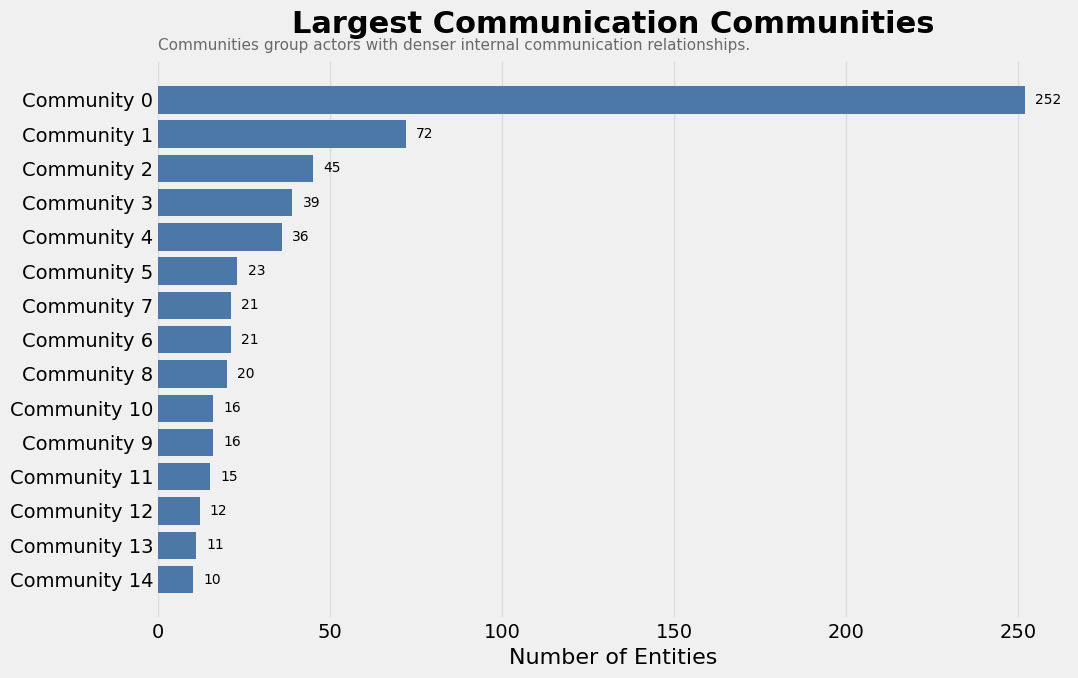

In [20]:
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

community_sizes_df = (
    pd.DataFrame({
        "community": range(len(community_sizes)),
        "size": community_sizes
    })
    .head(15)
    .sort_values("size")
)

community_sizes_df["label"] = (
    "Community "
    + community_sizes_df["community"].astype(str)
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    community_sizes_df["label"],
    community_sizes_df["size"],
    color="#4C78A8",
    edgecolor="none"
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Largest Communication Communities",
    fontsize=22,
    weight="bold",
    pad=20
)

ax.text(
    0,
    1.02,
    "Communities group actors with denser internal communication relationships.",
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

ax.set_xlabel(
    "Number of Entities",
    fontsize=16
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    color="#DDDDDD"
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The connected component and community analyses indicate that the network is neither a single homogeneous structure nor a collection of entirely isolated conversations.

Most actors belong to one large communication system, but that system contains internally concentrated clusters. These communities may reflect differences in professional roles, time periods, legal activity, media correspondence, personal relationships, or the source documents represented in the corpus.

Community membership therefore provides an additional retrieval signal for the broader GraphRAG framework. Rather than retrieving only documents associated with an individual actor, a network-informed system can retrieve evidence associated with the actor's surrounding communication community.

The next section visualizes these structural patterns and develops an interactive representation of the communication network.

# 8. Network Visualization

Network statistics provide quantitative evidence about communication patterns, but visual representations reveal structural properties that are often difficult to identify from tables alone.

This section presents several complementary visualizations of the communication network. Each visualization emphasizes a different aspect of the network:

* overall communication structure
* influential actors
* community organization
* interactive exploration

Together these visualizations provide an intuitive understanding of how communication is distributed across the network and complement the numerical analyses presented in earlier sections.

### Overall Communication Structure

The figure below visualizes the highest ranked portion of the communication network using a force directed (spring) layout.

Node size is proportional to weighted communication degree, while node color indicates detected community membership. Edges represent directed communication relationships.

Although simplified, the visualization illustrates several important structural characteristics:

* a highly centralized communication core
* numerous peripheral actors connected to the core
* several distinct community clusters
* limited communication between peripheral groups

This visualization provides a high level overview of the communication topology before examining the interactive network.

Static Network Visualization
-----------------------------------
Displayed nodes: 94
Displayed edges: 229


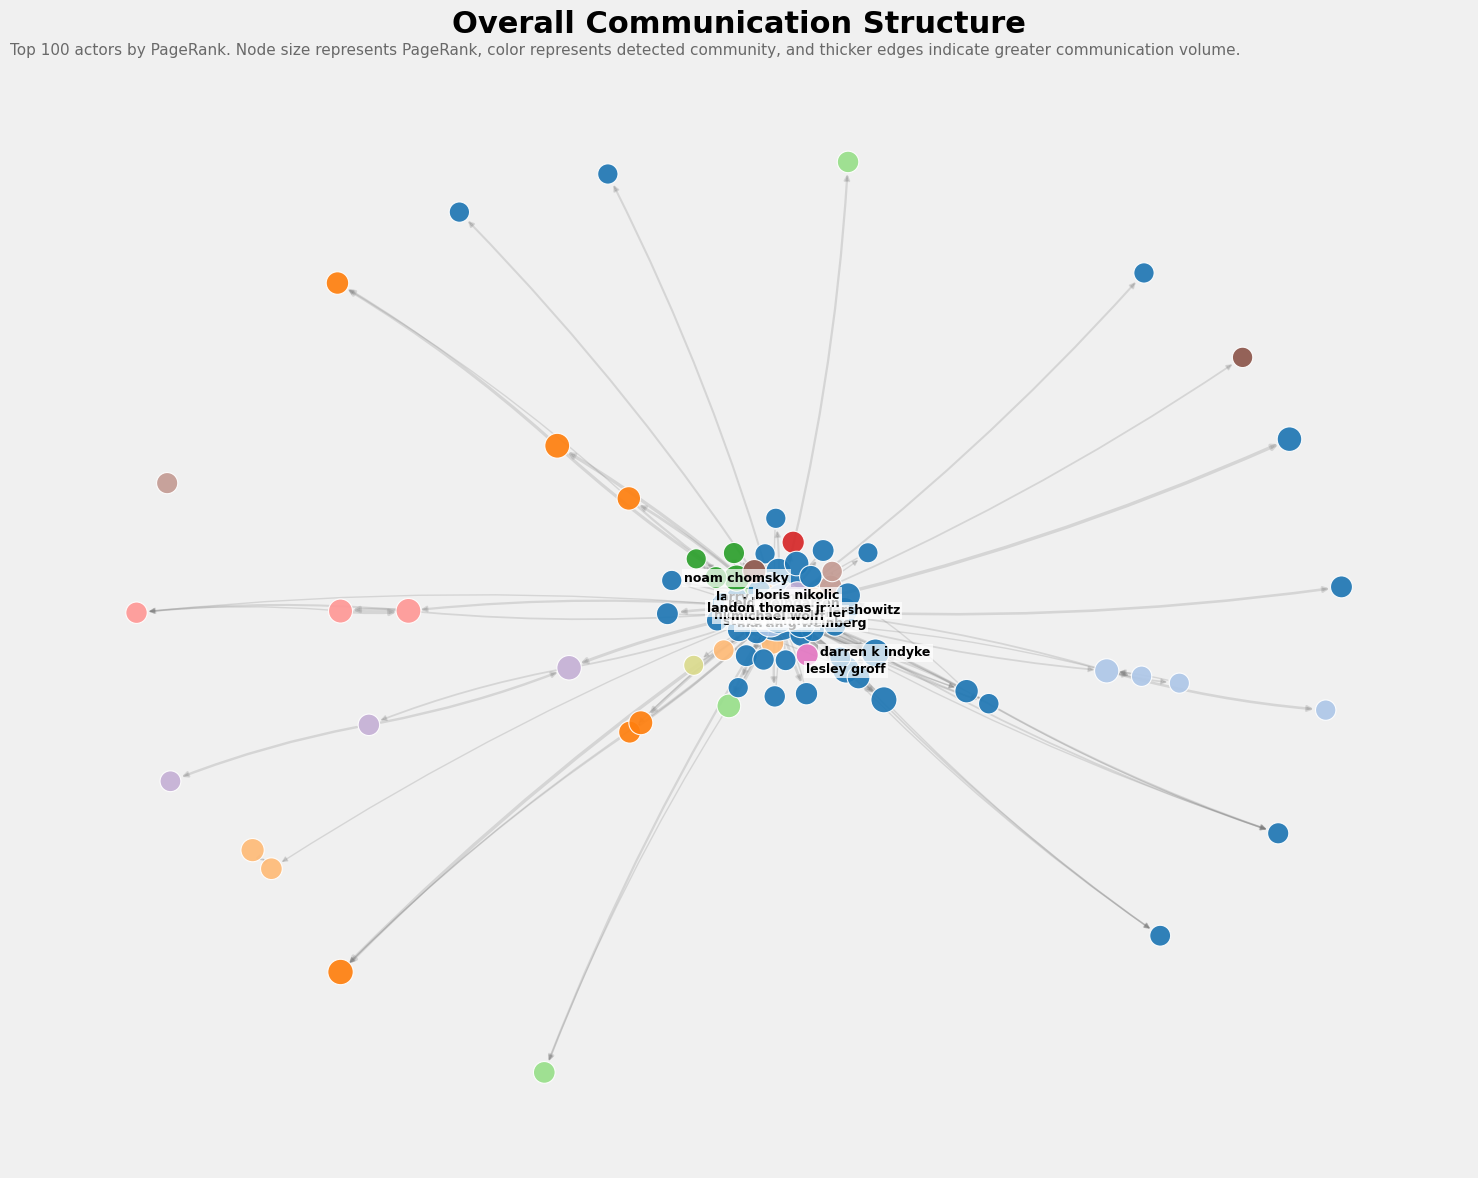

In [21]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

plt.style.use("fivethirtyeight")

# ---------------------------------------------------------
# 1. Select the most influential nodes for a readable plot
# ---------------------------------------------------------

top_node_ids = set(
    pagerank_df
    .head(100)["entity_id"]
)

G_plot = G_largest.subgraph(top_node_ids).copy()

print("Static Network Visualization")
print("-" * 35)
print(f"Displayed nodes: {G_plot.number_of_nodes():,}")
print(f"Displayed edges: {G_plot.number_of_edges():,}")


# ---------------------------------------------------------
# 2. Create lookup dictionaries
# ---------------------------------------------------------

name_lookup = (
    clean_nodes
    .set_index("entity_id")["canonical"]
    .to_dict()
)

pagerank_lookup = dict(
    zip(
        pagerank_df["entity_id"],
        pagerank_df["pagerank"]
    )
)

community_lookup = dict(
    zip(
        community_df["entity_id"],
        community_df["community"]
    )
)


# ---------------------------------------------------------
# 3. Define visual encodings
# ---------------------------------------------------------

node_sizes = [
    80 + (pagerank_lookup.get(node, 0) ** 0.5) * 4_000
    for node in G_plot.nodes()
]

node_colors = [
    community_lookup.get(node, -1)
    for node in G_plot.nodes()
]

edge_widths = [
    max(
        0.4,
        min(
            4,
            float(edge_data.get("weight", 1)) ** 0.35
        )
    )
    for _, _, edge_data in G_plot.edges(data=True)
]


# ---------------------------------------------------------
# 4. Compute a reproducible spring layout
# ---------------------------------------------------------

pos = nx.spring_layout(
    G_plot,
    seed=42,
    k=0.75,
    iterations=300,
    weight="weight"
)


# ---------------------------------------------------------
# 5. Draw the network
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 12)
)

nx.draw_networkx_edges(
    G_plot,
    pos,
    ax=ax,
    width=edge_widths,
    alpha=0.22,
    edge_color="#777777",
    arrows=True,
    arrowstyle="-|>",
    arrowsize=8,
    connectionstyle="arc3,rad=0.05"
)

nodes_artist = nx.draw_networkx_nodes(
    G_plot,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.92,
    linewidths=0.8,
    edgecolors="white"
)


# ---------------------------------------------------------
# 6. Label only the most influential actors
# ---------------------------------------------------------

label_ids = set(
    pagerank_df
    .head(15)["entity_id"]
)

labels = {
    node: name_lookup.get(node, str(node))
    for node in G_plot.nodes()
    if node in label_ids
}

nx.draw_networkx_labels(
    G_plot,
    pos,
    labels=labels,
    ax=ax,
    font_size=9,
    font_weight="bold",
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.72,
        "pad": 1.5
    }
)


# ---------------------------------------------------------
# 7. Titles and explanatory annotation
# ---------------------------------------------------------

ax.set_title(
    "Overall Communication Structure",
    fontsize=22,
    weight="bold",
    pad=24
)

ax.text(
    0,
    1.01,
    (
        "Top 100 actors by PageRank. "
        "Node size represents PageRank, color represents detected community, "
        "and thicker edges indicate greater communication volume."
    ),
    transform=ax.transAxes,
    fontsize=11,
    color="dimgray"
)

ax.axis("off")

plt.tight_layout()
plt.show()

### Visualization Interpretation

The static network displays the 100 highest ranked actors by PageRank within the largest weakly connected component.

The visualization highlights a strongly centralized structure in which a small number of influential actors occupy the communication core, while many others appear in peripheral positions. Node colors reveal that these influential actors belong to several detected communities rather than a single homogeneous group.

Because the visualization is restricted to the highest ranked actors, it should be interpreted as a structural summary of the network's most influential region rather than a complete representation of all 850 communication nodes.

### Interactive Network Exploration

The static visualization summarizes the network's most influential region, but it cannot support detailed inspection of individual actors and relationships.

The interactive network below displays the same top ranked portion of the communication graph while allowing users to drag nodes, zoom, search for specific actors, and inspect entity names by hovering. Clicking a node highlights its immediate communication neighborhood.

Node size represents PageRank, node color represents detected community, edge direction represents communication flow, and edge width reflects communication volume.

In [25]:
from pathlib import Path
import webbrowser

from IPython.display import IFrame, display
from pyvis.network import Network


# ---------------------------------------------------------
# 1. Select the top 100 PageRank nodes
# ---------------------------------------------------------

interactive_node_ids = set(
    pagerank_df
    .head(100)["entity_id"]
)

G_interactive = G_largest.subgraph(
    interactive_node_ids
).copy()

print("Interactive Network")
print("-" * 30)
print(f"Displayed nodes: {G_interactive.number_of_nodes():,}")
print(f"Displayed edges: {G_interactive.number_of_edges():,}")


# ---------------------------------------------------------
# 2. Build lookup dictionaries
# ---------------------------------------------------------

name_lookup = (
    clean_nodes
    .set_index("entity_id")["canonical"]
    .to_dict()
)

pagerank_lookup = dict(
    zip(
        pagerank_df["entity_id"],
        pagerank_df["pagerank"]
    )
)

community_lookup = dict(
    zip(
        community_df["entity_id"],
        community_df["community"]
    )
)


# ---------------------------------------------------------
# 3. Label only the 20 highest-ranked nodes
# ---------------------------------------------------------

top_label_ids = set(
    pagerank_df
    .head(20)["entity_id"]
)


# ---------------------------------------------------------
# 4. Community color palette
# ---------------------------------------------------------

community_palette = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
    "#72B7B2",
    "#B279A2",
    "#FF9DA6",
    "#9D755D",
    "#BAB0AC",
    "#EECA3B",
    "#5F9ED1",
    "#FAA43A",
    "#60BD68",
    "#F17CB0",
    "#B2912F",
    "#B276B2",
    "#DECF3F",
    "#F15854",
    "#76B7B2",
    "#A0CBE8",
]


def community_color(community_id):
    """Return a repeatable color for each detected community."""

    if community_id is None or community_id < 0:
        return "#BAB0AC"

    return community_palette[
        int(community_id) % len(community_palette)
    ]


# ---------------------------------------------------------
# 5. Create the PyVis network
# ---------------------------------------------------------

net = Network(
    height="850px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line",
    bgcolor="#FFFFFF",
    font_color="#222222",

    # Adds a searchable node menu.
    select_menu=True,

    # Clicking a node highlights its immediate neighborhood.
    neighborhood_highlight=True,
)


# ---------------------------------------------------------
# 6. Add nodes
# ---------------------------------------------------------

for node in G_interactive.nodes():

    name = name_lookup.get(
        node,
        str(node)
    )

    pagerank_value = float(
        pagerank_lookup.get(node, 0)
    )

    community_id = int(
        community_lookup.get(node, -1)
    )

    # Show permanent labels only for the top 20 PageRank nodes.
    # Every node still displays its canonical name on hover.
    visible_label = (
        str(name)
        if node in top_label_ids
        else ""
    )

    # Square-root scaling preserves PageRank ordering while preventing
    # the largest node from overwhelming the visualization.
    node_size = max(
        10,
        10 + (pagerank_value ** 0.5) * 90
    )

    fill_color = community_color(
        community_id
    )

    net.add_node(
        node,

        # Visible graph label.
        label=visible_label,

        # Hover tooltip.
        title=str(name),

        # PageRank controls node size.
        size=node_size,

        # Community controls node color.
        color={
            "background": fill_color,
            "border": "#FFFFFF",
            "highlight": {
                "background": fill_color,
                "border": "#111111"
            },
            "hover": {
                "background": fill_color,
                "border": "#111111"
            }
        },

        borderWidth=2,
        borderWidthSelected=5,

        # Extra properties remain available to PyVis.
        community=community_id,
        pagerank=round(
            pagerank_value,
            6
        )
    )


# ---------------------------------------------------------
# 7. Add directed communication edges
# ---------------------------------------------------------

for source, target, edge_data in G_interactive.edges(
    data=True
):

    weight = float(
        edge_data.get("weight", 1)
    )

    # Prevent high-volume edges from becoming excessively thick.
    edge_width = max(
        0.5,
        min(
            7,
            weight ** 0.35
        )
    )

    source_name = name_lookup.get(
        source,
        str(source)
    )

    target_name = name_lookup.get(
        target,
        str(target)
    )

    net.add_edge(
        source,
        target,

        # Edge hover tooltip.
        title=(
            f"{source_name} → {target_name}<br>"
            f"Messages sent: {weight:,.0f}"
        ),

        width=edge_width,
        arrows="to"
    )


# ---------------------------------------------------------
# 8. Interaction, labels, and force-directed layout
# ---------------------------------------------------------

net.set_options("""
{
  "interaction": {
    "hover": true,
    "hoverConnectedEdges": true,
    "navigationButtons": true,
    "keyboard": true,
    "multiselect": true,
    "selectConnectedEdges": true,
    "tooltipDelay": 100
  },

  "nodes": {
    "shape": "dot",
    "font": {
      "size": 12,
      "face": "Arial",
      "color": "#222222",
      "strokeWidth": 3,
      "strokeColor": "#ffffff"
    }
  },

  "edges": {
    "color": {
      "color": "rgba(115,115,115,0.32)",
      "highlight": "#222222",
      "hover": "#222222"
    },

    "arrows": {
      "to": {
        "enabled": true,
        "scaleFactor": 0.55
      }
    },

    "smooth": {
      "enabled": true,
      "type": "continuous",
      "roundness": 0.15
    }
  },

  "physics": {
    "enabled": true,
    "solver": "forceAtlas2Based",

    "forceAtlas2Based": {
      "gravitationalConstant": -85,
      "centralGravity": 0.008,
      "springLength": 145,
      "springConstant": 0.045,
      "damping": 0.55,
      "avoidOverlap": 0.8
    },

    "stabilization": {
      "enabled": true,
      "iterations": 1000,
      "updateInterval": 50,
      "fit": true
    }
  }
}
""")


# ---------------------------------------------------------
# 9. Save the interactive HTML file
# ---------------------------------------------------------

INTERACTIVE_DIR = (
    PROJECT_ROOT
    / "results"
    / "network_analysis"
)

INTERACTIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

interactive_path = (
    INTERACTIVE_DIR
    / "interactive_communication_network.html"
)

net.write_html(
    str(interactive_path),
    notebook=True
)

print("\nSaved interactive network to:")
print(interactive_path)


# ---------------------------------------------------------
# 10. Display inside the notebook
# ---------------------------------------------------------

display(
    IFrame(
        src=interactive_path.as_uri(),
        width="100%",
        height=850
    )
)


# ---------------------------------------------------------
# 11. Open the same graph in the default browser
# ---------------------------------------------------------

webbrowser.open(
    interactive_path.as_uri()
)

Interactive Network
------------------------------
Displayed nodes: 94
Displayed edges: 229

Saved interactive network to:
/Users/ethan/Desktop/DSAN 6400 - Network Analytics/DSAN-6400-Final-Project/results/network_analysis/interactive_communication_network.html


True

# 8. Interpretation and Conclusions

This analysis demonstrates that the Epstein communication network exhibits a highly centralized structure dominated by a relatively small number of influential actors. Across every centrality measure examined, Jeffrey Epstein consistently occupies the most prominent position within the network, reflecting both the highest communication volume and the greatest structural influence.

The centrality measures provide complementary perspectives on influence within the network. Weighted degree identifies individuals responsible for the greatest volume of direct communication, while PageRank highlights actors whose influence is reinforced through connections to other well connected individuals. Betweenness centrality identifies brokerage roles, revealing individuals that connect otherwise separate regions of the network and facilitate the flow of information between communities.

Community detection further demonstrates that the communication network is not homogeneous. Rather than consisting of a single densely connected group, the network is organized into multiple communities connected by a relatively small number of bridging actors. The interactive visualization reinforces these findings by allowing analysts to explore the network structure, examine local neighborhoods, and investigate the relationships between influential entities.

Together, these analyses illustrate how network science provides substantially richer insights than simple communication counts alone. By combining degree based metrics, recursive influence measures, brokerage analysis, community detection, and interactive visualization, the notebook provides a comprehensive structural view of the communication network extracted from the Epstein document corpus.

Several limitations should be considered when interpreting these results. The network is derived from the available document corpus rather than a complete historical record, and observed communication relationships do not necessarily represent every interaction between individuals. Furthermore, centrality measures quantify structural importance within the extracted network and should not be interpreted as measures of legal culpability or personal significance.

Overall, this notebook demonstrates a complete and reproducible network analysis workflow, beginning with a processed knowledge graph and progressing through data validation, network construction, structural analysis, community detection, and visualization. These results provide a strong foundation for future work using graph-based retrieval methods, temporal network analysis, and GraphRAG techniques to support investigative intelligence and large scale document exploration.